# Three flavours of conditional flow: base, coupling, both (and none)

`gauss_flows` makes three places conditional. This notebook reuses the **two-moons** dataset from notebook 01 (`gaussianization_flow_2d`) and conditions on the **class label** that notebook 01 throws away — `make_moons` returns `(X, y)` where `y ∈ {0, 1}` indicates which crescent each point belongs to. So $p(x \mid y=0)$ is the upper moon and $p(x \mid y=1)$ is the lower moon. We compare four configurations under the same hyperparameters:

1. **None** *(baseline = notebook 01's setup)*: a fixed `Normal(0, I)` base + unconditional `RQSplineCoupling` chain. The flow ignores $y$ entirely and fits the marginal — the full two-moons. Useful as a sanity check; reproduces notebook 01's fit quality.
2. **Base only**: a `ConditionalDiagGaussian` base whose mean / log-scale come from the one-hot $y$, paired with the same unconditional `RQSplineCoupling` chain. The base shifts per class but the chain learns one shared crescent shape.
3. **Coupling only**: a fixed `Normal(0, I)` base, paired with `RQSplineCoupling(cond_dim=2)` layers that read the one-hot $y$. The couplings learn class-specific shapes, but they have to absorb any class-specific shift through the spline parameters — awkward.
4. **Both**: conditional base **and** conditional couplings — the same one-hot label flows to both. Full capacity.

The same `condition` keyword threads through every layer that opts in; layers that did not (`cond_shape is None`) silently ignore it. This is documented in `SurVAEFlow`'s "Conditioning model" section.


In [1]:
from __future__ import annotations

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from flowjax.bijections import Permute
from flowjax.distributions import AbstractDistribution, Normal
from flowjax.train import fit_to_data
from sklearn.datasets import make_moons

from gauss_flows import ConditionalDiagGaussian, RQSplineCoupling, SurVAEFlow


# --- global plot styling (matches docs/notebooks/01_gaussianization_flow_2d) ----
sns.set_theme(context="poster", style="whitegrid", palette="deep", font_scale=0.85)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.constrained_layout.use": True,
        "figure.constrained_layout.h_pad": 0.1,
        "figure.constrained_layout.w_pad": 0.1,
        "axes.grid.which": "both",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.5,
        "axes.edgecolor": "0.25",
        "axes.linewidth": 1.1,
        "axes.titleweight": "semibold",
        "axes.labelpad": 6,
    }
)


def style_axes(ax, *, aspect=None, grid=True):
    if grid:
        ax.minorticks_on()
        ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
        ax.grid(True, which="minor", linewidth=0.4, alpha=0.3)
    if aspect is not None:
        ax.set_aspect(aspect)
    return ax


def style_jointgrid(g, aspect="equal"):
    style_axes(g.ax_joint, aspect=aspect)
    style_axes(g.ax_marg_x, grid=False)
    style_axes(g.ax_marg_y, grid=False)
    for spine in ("top", "right"):
        g.ax_marg_x.spines[spine].set_visible(False)
        g.ax_marg_y.spines[spine].set_visible(False)


palette = sns.color_palette("deep")

/home/azureuser/localfiles/gauss_flows/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data

Same `make_moons(...)` call as notebook 01, but we keep the class label and one-hot encode it as the condition $c \in \{(1, 0), (0, 1)\}$.

In [2]:
X_raw, y = make_moons(n_samples=5000, noise=0.05, random_state=0)
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
X = jnp.asarray(X, dtype=jnp.float32)
C = jax.nn.one_hot(jnp.asarray(y, dtype=jnp.int32), num_classes=2)
print(f"X.shape={X.shape}, C.shape={C.shape}")
print(f"counts per class: y=0 -> {int((y == 0).sum())}, y=1 -> {int((y == 1).sum())}")

X.shape=(5000, 2), C.shape=(5000, 2)
counts per class: y=0 -> 2500, y=1 -> 2500


/home/azureuser/localfiles/gauss_flows/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


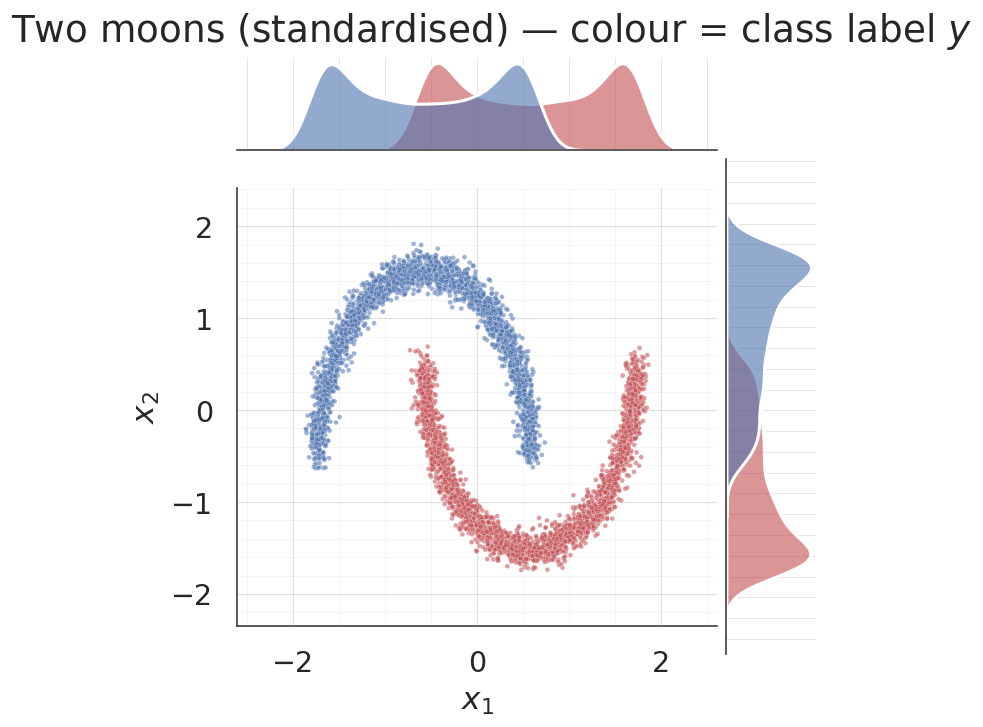

In [3]:
# Show the marginal as a jointplot (matches notebook 01's data overview),
# colour-coded by class so the conditional structure is obvious.
g = sns.jointplot(
    x=np.asarray(X[:, 0]),
    y=np.asarray(X[:, 1]),
    hue=np.asarray(y),
    palette={0: palette[0], 1: palette[3]},
    kind="scatter",
    height=6.5,
    ratio=5,
    space=0.1,
    joint_kws={"s": 10, "alpha": 0.55},
    marginal_kws={"alpha": 0.6, "edgecolor": "white"},
    legend=False,
)
g.set_axis_labels("$x_1$", "$x_2$")
g.figure.suptitle("Two moons (standardised) — colour = class label $y$", y=1.02)
style_jointgrid(g)
plt.show()

## 2. Four flow configurations

Each flow uses the same chain of four `RQSplineCoupling` layers separated by fixed permutations — splines for capacity, since fitting two-moons is not affine. The only difference between the four configurations is *where* conditioning happens.

| Flow | Base | Couplings | What can it model? |
|---|---|---|---|
| `flow_none` | `Normal(0, I)` | unconditional | only the marginal $p(x)$ — ignores $y$ |
| `flow_base` | `ConditionalDiagGaussian` | unconditional | per-class shift only |
| `flow_coupling` | `Normal(0, I)` | `cond_dim=2` | per-class shape warps |
| `flow_both` | `ConditionalDiagGaussian` | `cond_dim=2` | both — full capacity |


In [4]:
N_LAYERS = 4
EVENT = (2,)
COND_DIM = 2  # one-hot (2,)


def make_flow(*, base_cond: bool, coupling_cond: bool, key):
    """Build an N_LAYERS-layer SurVAEFlow with the requested conditioning."""
    base_key, *layer_keys, perm_key = jr.split(key, N_LAYERS + 2)
    if base_cond:
        base = ConditionalDiagGaussian(
            base_key, event_shape=EVENT, cond_shape=(COND_DIM,)
        )
    else:
        base = Normal(jnp.zeros(EVENT))
    cond_dim = COND_DIM if coupling_cond else None
    perm = jr.permutation(perm_key, jnp.arange(EVENT[0]))
    transforms = []
    for i, k in enumerate(layer_keys):
        transforms.append(
            RQSplineCoupling(
                k,
                shape=EVENT,
                n_bins=8,
                interval=4.0,
                cond_dim=cond_dim,
                nn_width=64,
                nn_depth=2,
            )
        )
        if i < N_LAYERS - 1:
            transforms.append(Permute(perm))
    return SurVAEFlow(base, transforms)


CONFIGS = [
    ("none", dict(base_cond=False, coupling_cond=False)),
    ("base only", dict(base_cond=True, coupling_cond=False)),
    ("coupling only", dict(base_cond=False, coupling_cond=True)),
    ("both", dict(base_cond=True, coupling_cond=True)),
]
flows = {
    name: make_flow(**kw, key=jr.key(11 + i)) for i, (name, kw) in enumerate(CONFIGS)
}
for name, flow in flows.items():
    n_params = sum(
        int(np.prod(p.shape))
        for p in jax.tree_util.tree_leaves(eqx.filter(flow, eqx.is_array))
    )
    print(f"{name:>14s}  trainable params: {n_params:6d}")

          none  trainable params:  24448
     base only  trainable params:  29056
 coupling only  trainable params:  24960
          both  trainable params:  29568


## 3. Train each flow

Wrap `SurVAEFlow` as a `flowjax.distributions.AbstractDistribution` so `fit_to_data` can auto-vmap over the batch. Same hyperparameters across configurations (matching notebook 01: `learning_rate=5e-3`, `batch_size=256`, `max_epochs=600`).

In [5]:
class SurVAEFlowAdapter(AbstractDistribution):
    """Adapt a bijection-only SurVAEFlow to flowjax's AbstractDistribution API.

    SurVAEFlow.log_prob has signature (x, key, condition); flowjax expects
    (x, condition) and auto-vmaps over batched x and condition. The key in
    SurVAEFlow's signature is consumed by stochastic surjections only; for
    a bijection-only chain it is unused, so we fix it deterministically.
    """

    flow: SurVAEFlow
    shape: tuple[int, ...]
    cond_shape: tuple[int, ...] | None

    def __init__(self, flow):
        self.flow = flow
        self.shape = flow.data_shape
        # Always declare cond_shape so the adapter accepts a context. The
        # "none" flow internally ignores it (no opted-in layers).
        self.cond_shape = (COND_DIM,)

    def _log_prob(self, x, condition=None):
        return self.flow.log_prob(x, jr.key(0), condition=condition)

    def _sample(self, key, condition=None):
        return self.flow.sample(key, condition=condition)


def train(flow, *, key):
    adapter = SurVAEFlowAdapter(flow)
    trained, losses = fit_to_data(
        key,
        adapter,
        (X, C),
        learning_rate=5e-3,
        max_epochs=600,
        max_patience=30,
        batch_size=256,
        val_prop=0.1,
        show_progress=False,
    )
    return trained.flow, losses


trained = {}
losses_all = {}
for name, _ in CONFIGS:
    print(f"training: {name}")
    trained[name], losses_all[name] = train(
        flows[name], key=jr.key(20 + abs(hash(name)) % 1000)
    )

training: none


training: base only


training: coupling only


training: both


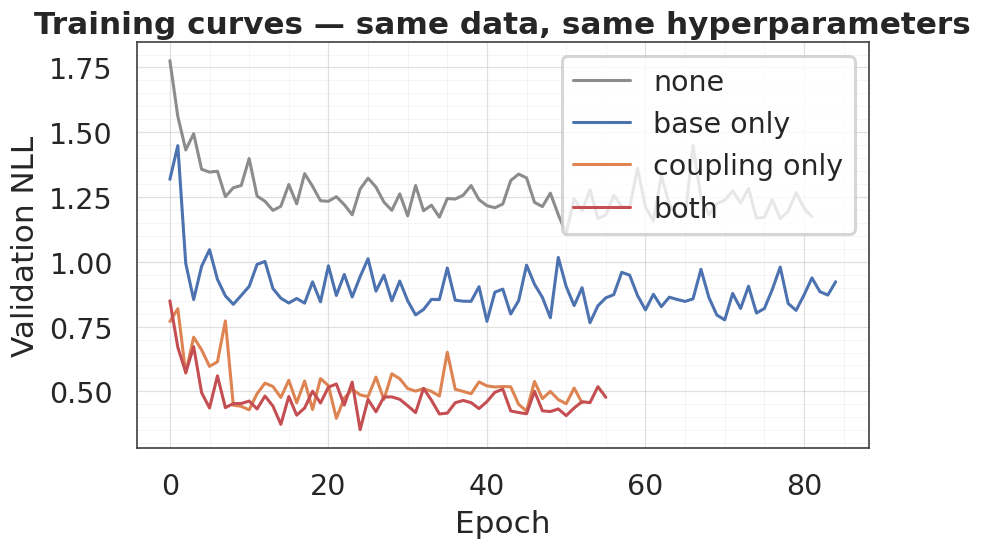

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
config_palette = {
    "none": palette[7],
    "base only": palette[0],
    "coupling only": palette[1],
    "both": palette[3],
}
for name, _ in CONFIGS:
    losses = losses_all[name]
    ax.plot(losses["val"], label=name, color=config_palette[name], linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation NLL")
ax.set_title("Training curves — same data, same hyperparameters")
ax.legend(frameon=True)
style_axes(ax)
plt.show()

## 4. Per-class sample comparison

Two rows (one per class) × four columns (one per configuration). Each panel overlays flow samples (config colour) on the true samples for that class (light blue). The "none" flow has no class information — its panel is the same in both rows by construction.

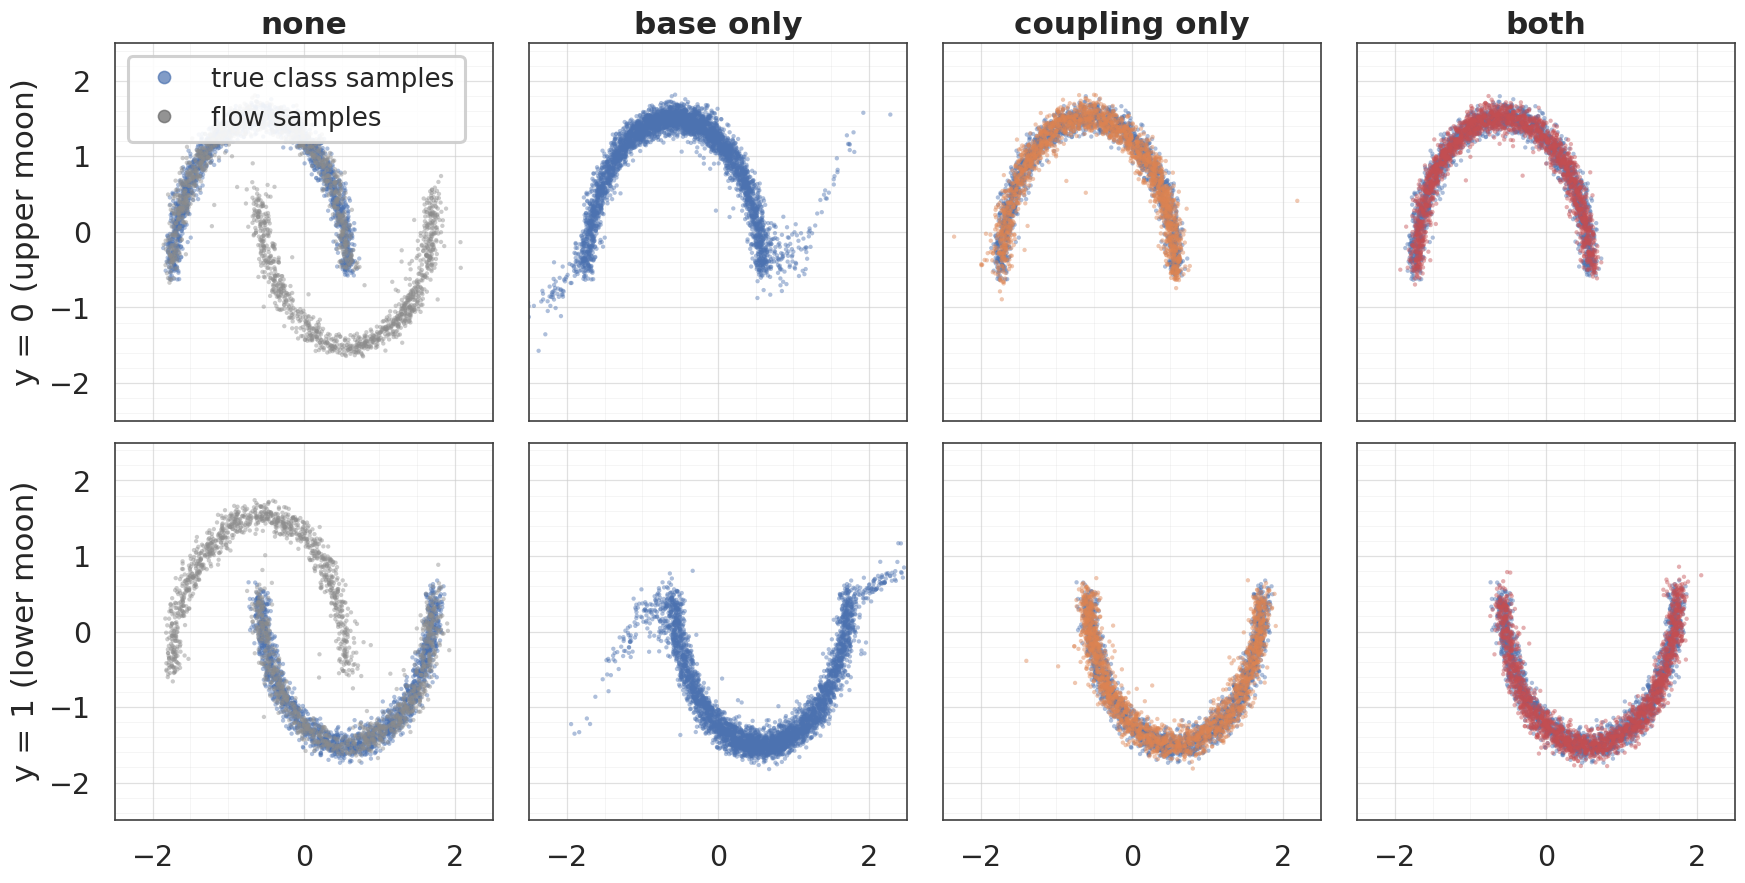

In [7]:
eval_classes = jnp.array(
    [
        [1.0, 0.0],  # y = 0  → upper moon
        [0.0, 1.0],  # y = 1  → lower moon
    ],
    dtype=jnp.float32,
)
class_labels_text = ["y = 0 (upper moon)", "y = 1 (lower moon)"]

n_per_panel = 2000


def true_class_samples(class_idx):
    mask = y == class_idx
    return X[mask][:n_per_panel]


def flow_samples(flow, n, c, *, key):
    cond = jnp.broadcast_to(c, (n, COND_DIM))
    keys = jr.split(key, n)
    return jax.vmap(lambda k, ci: flow.sample(k, condition=ci))(keys, cond)


config_names = ["none", "base only", "coupling only", "both"]
n_rows = len(eval_classes)
n_cols = len(config_names)

lim = 2.5
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(4.0 * n_cols, 4.0 * n_rows),
    sharex=True,
    sharey=True,
)

for row, (c, label_text) in enumerate(zip(eval_classes, class_labels_text)):
    class_idx = int(jnp.argmax(c))
    true_s = true_class_samples(class_idx)
    for col, name in enumerate(config_names):
        flow_s = flow_samples(
            trained[name],
            n_per_panel,
            c,
            key=jr.fold_in(jr.key(100 + col), row),
        )
        ax = axes[row, col]
        ax.scatter(
            np.asarray(true_s[:, 0]),
            np.asarray(true_s[:, 1]),
            s=8,
            alpha=0.45,
            color=palette[0],
            label="true",
            edgecolors="none",
        )
        ax.scatter(
            np.asarray(flow_s[:, 0]),
            np.asarray(flow_s[:, 1]),
            s=8,
            alpha=0.45,
            color=config_palette[name],
            label="flow",
            edgecolors="none",
        )
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        if row == 0:
            ax.set_title(name)
        if col == 0:
            ax.set_ylabel(label_text)
        style_axes(ax, aspect="equal")

handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markersize=8,
        alpha=0.7,
        color=palette[0],
        label="true class samples",
    ),
    plt.Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markersize=8,
        alpha=0.7,
        color="0.4",
        label="flow samples",
    ),
]
axes[0, 0].legend(handles=handles, loc="upper left", fontsize="small", framealpha=0.9)
plt.show()

**What to look for**

- **None** (column 1): the flow ignores $y$ — it samples from the *full* two-moons every time, so half the samples land in the wrong crescent. The light blue (true class) and orange (flow) only partially overlap.
- **Base only** (column 2): the per-class mean is correct, but the unconditional spline chain learned one shape that has to serve both classes — the per-class crescent shape is muddier than the truth.
- **Coupling only** (column 3): the spline couplings can read the one-hot label and produce class-specific crescents. Position and shape both come out cleanly because the couplings have enough capacity to absorb the per-class shift through the spline parameters.
- **Both** (column 4): same crisp per-class fit as coupling-only, with the conditional base providing a per-class warm-start. The end-game NLL is the lowest.


## 5. Quantitative comparison

Mean per-example log-likelihood on the training set (we have no held-out oracle, but the four configurations can still be ranked).

In [8]:
def mean_flow_lp(flow):
    @eqx.filter_jit
    def f(x, c):
        return jax.vmap(lambda xi, ci: flow.log_prob(xi, jr.key(0), condition=ci))(x, c)

    return jnp.mean(f(X, C))


for name, _ in CONFIGS:
    print(f"{name:<14s}: {float(mean_flow_lp(trained[name])):+.4f}")

none          : -1.1625


base only     : -0.8152


coupling only : -0.4704


both          : -0.4593


## 6. Takeaways

- **Pick what to condition based on what your data needs.** If only the *position* of $p(x|c)$ varies with $c$, a conditional base alone is enough. If the *shape* varies (as it does here — each class is a different crescent), conditional couplings are the natural fit. Real datasets usually benefit from both.
- **The same `condition` keyword threads everywhere.** `SurVAEFlow.log_prob(x, key, condition=c)` broadcasts $c$ to every layer that opted in (`cond_shape is not None`); other layers ignore it. There is no per-layer condition kwarg.
- **Inside a coupling there are two streams.** The `untransformed` half of $x$ is *always* a conditioning input — that is how coupling layers work. Adding `cond_dim > 0` *also* concatenates the external context onto the inner MLP. The two streams are merged inside flowjax and you never slice them apart.
- **For class-conditional density estimation,** prefer `ClassCondFlow(n_classes=..., event_shape=..., transforms=[...])` — it pairs a `ClassCondDiagGaussian` base (per-class learnable loc / log-scale) with an arbitrary chain of *unconditional* transforms, exposing a `label` keyword instead of `condition`.
- **For transforms that genuinely cannot take a condition** (rotations, normalisations, etc.), wrap them in `Conditioner(inner=..., cond_shape=...)` to add a context-amortised affine modulation around the inner transform.
